In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
eonly = pd.read_csv("eonly_pathfinding_results.csv")
ionly = pd.read_csv("ionly_pathfinding_results.csv")
eonly

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1
0,CL099b,AVLP178,2,True,True,False,False,False,False
1,CL099b,AVLP178,3,True,True,False,False,False,False
2,CL099b,AVLP178,4,True,True,False,False,False,False
3,CL099b,AVLP178,5,True,True,False,False,False,False
4,CL099b,CB2309,2,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
3999995,SMP550,CB0150,5,True,True,True,False,False,False
3999996,SMP550,FB2J_b,2,True,False,False,False,False,False
3999997,SMP550,FB2J_b,3,True,True,False,False,False,False
3999998,SMP550,FB2J_b,4,True,True,False,False,False,False


In [3]:
# make longer: all columns starting with 'threshold'
eonly = eonly.melt(id_vars=['plen','pre','post'], value_vars=[col for col in eonly.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
eonly['threshold'] = eonly['threshold'].str.replace('threshold_','')
eonly['plen'] = eonly['plen'].astype(str)

ionly = ionly.melt(id_vars=['plen','pre','post'], value_vars=[col for col in ionly.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
ionly['threshold'] = ionly['threshold'].str.replace('threshold_','')
ionly['plen'] = ionly['plen'].astype(str)

only = eonly.merge(ionly, on=['plen','pre','post','threshold'], suffixes=('_eonly', '_ionly'))
only

,plen,pre,post,threshold,value_eonly,value_ionly
0,2,WED017,AVLP178,0,True,False
1,3,WED017,AVLP178,0,True,False
2,4,WED017,AVLP178,0,True,False
3,5,WED017,AVLP178,0,True,False
4,2,WED017,CB2309,0,True,False
...,...,...,...,...,...,...
239995,5,CB1279,AVLP339,0.1,False,False
239996,2,CB1279,CB2694,0.1,False,False
239997,3,CB1279,CB2694,0.1,False,False
239998,4,CB1279,CB2694,0.1,False,False


In [4]:
# both e and i 
both = pd.read_csv("../path_effconn_benchmark/results.csv")

# make longer: all columns starting with 'threshold'
both = both.melt(id_vars=['plen','pre','post'], value_vars=[col for col in both.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
both['threshold'] = both['threshold'].str.replace('threshold_','')
both['plen'] = both['plen'].astype(str)
both

,plen,pre,post,threshold,value
0,2,MBON32,AVLP178,0,True
1,3,MBON32,AVLP178,0,True
2,4,MBON32,AVLP178,0,True
3,5,MBON32,AVLP178,0,True
4,2,MBON32,CB2309,0,True
...,...,...,...,...,...
268795,5,MLt3,AVLP339,0.1,False
268796,2,MLt3,CB2694,0.1,False
268797,3,MLt3,CB2694,0.1,False
268798,4,MLt3,CB2694,0.1,False


In [5]:
# all together 
eib = both.merge(only, on=['plen','pre','post','threshold']).rename(columns={'value': 'value_both'})
eib

,plen,pre,post,threshold,value_both,value_eonly,value_ionly
0,2,MBON32,AVLP178,0,True,False,True
1,3,MBON32,AVLP178,0,True,False,True
2,4,MBON32,AVLP178,0,True,False,True
3,5,MBON32,AVLP178,0,True,False,True
4,2,MBON32,CB2309,0,True,False,True
...,...,...,...,...,...,...,...
239995,5,CB1080,AVLP339,0.1,False,False,False
239996,2,CB1080,CB2694,0.1,False,False,False
239997,3,CB1080,CB2694,0.1,False,False,False
239998,4,CB1080,CB2694,0.1,False,False,False


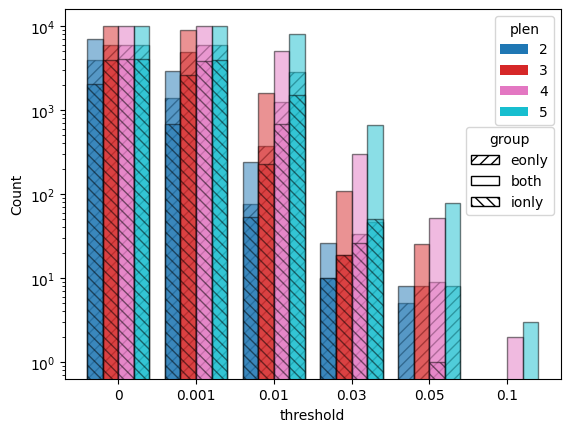

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plen_values = sorted(eib['plen'].unique())
thresholds = sorted(eib['threshold'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(plen_values)))

fig, ax = plt.subplots()
x = np.arange(len(thresholds))
width = 0.8 / len(plen_values)

for i, plen in enumerate(plen_values):
    data = eib[eib['plen'] == plen]
    pos = x + i * width - 0.4 + width/2
    
    counts_e = [sum((data.value_eonly) & (data['threshold'] == t)) for t in thresholds]
    ax.bar(pos, counts_e, width, color=colors[i], edgecolor='black', hatch='///', alpha=0.5)
    
    counts_b = [sum((data.value_both) & (data['threshold'] == t)) for t in thresholds]
    ax.bar(pos, counts_b, width, color=colors[i], edgecolor='black', alpha=0.5)
    
    counts_i = [sum((data.value_ionly) & (data['threshold'] == t)) for t in thresholds]
    ax.bar(pos, counts_i, width, color=colors[i], edgecolor='black', hatch='\\\\\\', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.set_yscale('log')
ax.set_xlabel('threshold')
ax.set_ylabel('Count')

plen_handles = [mpatches.Patch(facecolor=colors[i], label=str(p)) for i, p in enumerate(plen_values)]
leg1 = ax.legend(handles=plen_handles, title='plen', loc='upper right', bbox_to_anchor=(1, 1))
ax.add_artist(leg1)

group_handles = [mpatches.Patch(facecolor='white', edgecolor='black', hatch=h, label=l) 
                 for h, l in [('///', 'eonly'), ('', 'both'), ('\\\\\\', 'ionly')]]
ax.legend(handles=group_handles, title='group', loc='upper right', bbox_to_anchor=(1, 0.7))

plt.show()